#**Name: Mai Hashad**

# Chapter 2: Text Classification

## The Dataset

### A First Look at Hugging Face Datasets

In [1]:
# Setting up a connection to the Hugging Face Hub to load datasets
# list_datasets() shows datasets available to use
# Print 10 of these datasets

from huggingface_hub import list_datasets

# Convert generator to list
all_datasets = list(list_datasets())

print(f"There are {len(all_datasets)} datasets currently available on the Hub")
print(f"The first 10 are: {all_datasets[:10]}")

There are 340218 datasets currently available on the Hub
The first 10 are: [DatasetInfo(id='nvidia/Llama-Nemotron-Post-Training-Dataset-v1', author='nvidia', sha='ed905e6239c9d191e4c965a403dde07a5383b5eb', created_at=datetime.datetime(2025, 3, 13, 21, 1, 9, tzinfo=datetime.timezone.utc), last_modified=datetime.datetime(2025, 3, 18, 15, 56, 14, tzinfo=datetime.timezone.utc), private=False, gated=False, disabled=False, downloads=6212, downloads_all_time=None, likes=243, paperswithcode_id=None, tags=['license:cc-by-4.0', 'size_categories:10M<n<100M', 'format:json', 'modality:text', 'library:datasets', 'library:pandas', 'library:mlcroissant', 'library:polars', 'region:us'], trending_score=137, card_data=None, siblings=None), DatasetInfo(id='glaiveai/reasoning-v1-20m', author='glaiveai', sha='da6bb3d0ff8fd8ea5abacee8519762ca6aaf367e', created_at=datetime.datetime(2025, 2, 27, 20, 40, 5, tzinfo=datetime.timezone.utc), last_modified=datetime.datetime(2025, 3, 19, 13, 21, 37, tzinfo=datetime.t

In [2]:
#!pip uninstall datasets -y
!pip install datasets

In [3]:
# Using Emtoion dataset
# Contains 6 emotions: [ anger, disgust, fear, joy, sadness, surprise]

from datasets import load_dataset
emotions = load_dataset("emotion")

In [4]:
# Print structure of the dataset [train, test, val]

emotions

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [5]:
# The emtions object acts like a dictionary and its train sbuset can be accessed with the key
# Create a dataset out of the train subset of the emotions dataset

train_ds = emotions["train"]
train_ds

Dataset({
    features: ['text', 'label'],
    num_rows: 16000
})

In [6]:
# Print the number of records in the new train dataset
# The train dataset object acts like an array that we can query its length

len(train_ds)

16000

In [7]:
# Show the first record in the train dataset
train_ds[0]

{'text': 'i didnt feel humiliated', 'label': 0}

In [8]:
# Show the column names in the train dataset
# The train_ds is represented like a dictionary with the keys corresponding to the column names

train_ds.column_names

['text', 'label']

In [9]:
# Show the feature names and datatypes of the columns in the train dataset
# The label column is a ClassLabel object that contains information about the class names and their mapping to integers

print(train_ds.features)

{'text': Value(dtype='string', id=None), 'label': ClassLabel(names=['sadness', 'joy', 'love', 'anger', 'fear', 'surprise'], id=None)}


In [10]:
#Accessing several rows with a slice

print(train_ds[:5])

{'text': ['i didnt feel humiliated', 'i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake', 'im grabbing a minute to post i feel greedy wrong', 'i am ever feeling nostalgic about the fireplace i will know that it is still on the property', 'i am feeling grouchy'], 'label': [0, 0, 3, 2, 3]}


In [11]:
# Getting a column value for several  records/ rows

print(train_ds["text"][:5])

['i didnt feel humiliated', 'i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake', 'im grabbing a minute to post i feel greedy wrong', 'i am ever feeling nostalgic about the fireplace i will know that it is still on the property', 'i am feeling grouchy']


### What If My Dataset Is Not on the Hub

In [12]:
# Running a shell command to get the source files for the emotion dataset from Dropbox

dataset_url = "https://huggingface.co/datasets/transformersbook/emotion-train-split/raw/main/train.txt"
!wget {dataset_url}

--2025-03-27 03:08:54--  https://huggingface.co/datasets/transformersbook/emotion-train-split/raw/main/train.txt
Resolving huggingface.co (huggingface.co)... 18.172.134.88, 18.172.134.124, 18.172.134.24, ...
Connecting to huggingface.co (huggingface.co)|18.172.134.88|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1658616 (1.6M) [text/plain]
Saving to: ‘train.txt.1’

train.txt.1         100%[===================>]   1.58M  --.-KB/s    in 0.07s   

2025-03-27 03:08:54 (23.5 MB/s) - ‘train.txt.1’ saved [1658616/1658616]



In [13]:
# Running a shell command to display the first row of the train.txt file

!head -n 1 train.txt

i didnt feel humiliated;sadness


In [14]:
# Loading the dataset locally by using the CSV script and pointing the data_files argument to the train.txt file

emotions_local = load_dataset("csv", data_files="train.txt", sep=";", names=["text", "label"])

In [15]:
# Simpler approach -  point the data_files argument to the URL directly
# Load the datasets from Dropbox, reading from the train.txt file and using CVS and ";" delimeter to split the cells in each record

dataset_url = "https://huggingface.co/datasets/transformersbook/emotion-train-split/raw/main/train.txt"
emotions_remote = load_dataset("csv", data_files=dataset_url, sep=";",
                               names=["text", "label"])

### From Datasets to Data Frames

In [16]:
# Convert Dataset to Dataframes for higher level API calls

import pandas as pd

emotions.set_format(type="pandas")
df = emotions["train"][:]
df.head()

,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3


In [17]:
#Create a new column to represent the string value of the labels uby using the int2str method

def label_int2str(row):
    return emotions["train"].features["label"].int2str(row)

df["label_name"] = df["label"].apply(label_int2str)
df.head()

,text,label,label_name
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger


### Looking at the Class Distribution

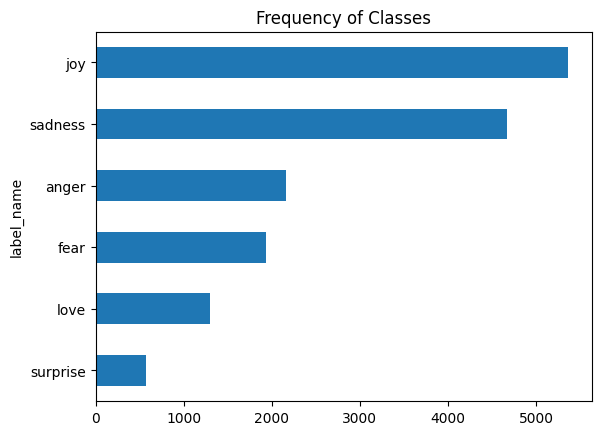

In [18]:
# Visualizing the class distribution of label names
# Data is skewed - Joy and sadness much more that surprise and love

import matplotlib.pyplot as plt

df["label_name"].value_counts(ascending=True).plot.barh()
plt.title("Frequency of Classes")
plt.show()

### How Long Are Our Tweets?

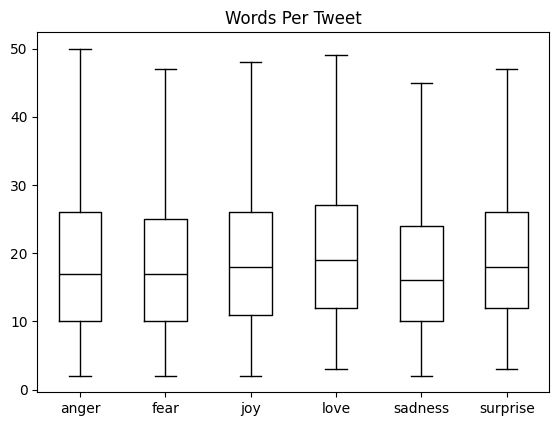

In [19]:
# Display the distribution of words per tweet
# Longest tweets (~50 words) are below DistilBERT's limit
# Most tweets are ~15 words

df["Words Per Tweet"] = df["text"].str.split().apply(len)
df.boxplot("Words Per Tweet", by="label_name", grid=False,
          showfliers=False, color="black")
plt.suptitle("")
plt.xlabel("")
plt.show()

In [20]:
# Removing the Dataframe format

emotions.reset_format()

## From Text to Tokens

### Character Tokenization

In [21]:
# Implementing character-level tokenization

text = "Tokenizing text is a core task of NLP."
tokenized_text = list(text)
print(tokenized_text)

['T', 'o', 'k', 'e', 'n', 'i', 'z', 'i', 'n', 'g', ' ', 't', 'e', 'x', 't', ' ', 'i', 's', ' ', 'a', ' ', 'c', 'o', 'r', 'e', ' ', 't', 'a', 's', 'k', ' ', 'o', 'f', ' ', 'N', 'L', 'P', '.']


In [22]:
# Implementing numericalization
# Gives us a mapping from each character to a unique integer

token2idx = {ch: idx for idx, ch in enumerate(sorted(set(tokenized_text)))}
print(token2idx)


{' ': 0, '.': 1, 'L': 2, 'N': 3, 'P': 4, 'T': 5, 'a': 6, 'c': 7, 'e': 8, 'f': 9, 'g': 10, 'i': 11, 'k': 12, 'n': 13, 'o': 14, 'r': 15, 's': 16, 't': 17, 'x': 18, 'z': 19}


In [23]:
# Using token2idx to transform the tokenized text to a list of integers

input_ids = [token2idx[token] for token in tokenized_text]
print(input_ids)

[5, 14, 12, 8, 13, 11, 19, 11, 13, 10, 0, 17, 8, 18, 17, 0, 11, 16, 0, 6, 0, 7, 14, 15, 8, 0, 17, 6, 16, 12, 0, 14, 9, 0, 3, 2, 4, 1]


In [24]:
# Applying OHE on Categorical Data
# Possible Issue: creates a fictitious ordering between the names

categorical_df = pd.DataFrame(
    {"Name": ["Bumblebee", "Optimus Prime", "Megatron"], "Label ID": [0,1,2]})
categorical_df

,Name,Label ID
0,Bumblebee,0
1,Optimus Prime,1
2,Megatron,2


In [25]:
# Workaround: create a new column for each category and assign a 1 where the category is true, and a 0 otherwise.

pd.get_dummies(categorical_df["Name"])

,Bumblebee,Megatron,Optimus Prime
0,True,False,False
1,False,False,True
2,False,True,False


In [26]:
# Applying OHE on input tokenized array
# With one_hot(): For each of the 38 input tokens, there is a one-hot vector with 20 dimensions (# of distinct characters = 20)

import torch
import torch.nn.functional as F

input_ids = torch.tensor(input_ids)
one_hot_encodings = F.one_hot(input_ids, num_classes=len(token2idx))
one_hot_encodings.shape

torch.Size([38, 20])

In [27]:
# Vefiying created tensor

print(f"Token: {tokenized_text[0]}")
print(f"Tensor index: {input_ids[0]}")
print(f"One-hot: {one_hot_encodings[0]}")

Token: T
Tensor index: 5
One-hot: tensor([0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])


### Word Tokenization

In [28]:
# Splitting Text into word tokens
# Word Tokenization uses less compute, memory, and data than characher tokenization

tokenized_text = text.split()
print(tokenized_text)

['Tokenizing', 'text', 'is', 'a', 'core', 'task', 'of', 'NLP.']


### Subword Tokenization

In [29]:
# Load the tokenizer distilbert-base-uncased (DistilBERT) using the transformer AutoTokenizer
from transformers import AutoTokenizer

model_ckpt = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)

In [30]:
# Loading the DistilBERT tokenizer manually wihout using the Autotokenizer

from transformers import DistilBertTokenizer

distilbert_tokenizer = DistilBertTokenizer.from_pretrained(model_ckpt)

In [31]:
# Running the tokenizer on a text string

encoded_text = tokenizer(text)
print(encoded_text)

{'input_ids': [101, 19204, 6026, 3793, 2003, 1037, 4563, 4708, 1997, 17953, 2361, 1012, 102], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}


In [32]:
# Covert integer tokens back into words
# [CLS] and [SEP] indicate the start and end of a sequence
# The tokens have each been lowercased
# “tokenizing” and “NLP” have been split into two tokens since they are not common words.
# The "##" prefix means it's not preceded by white space

tokens = tokenizer.convert_ids_to_tokens(encoded_text.input_ids)
print(tokens)

['[CLS]', 'token', '##izing', 'text', 'is', 'a', 'core', 'task', 'of', 'nl', '##p', '.', '[SEP]']


In [33]:
# Convert the tokenized array into a text string again

print(tokenizer.convert_tokens_to_string(tokens))

[CLS] tokenizing text is a core task of nlp. [SEP]


In [34]:
# Inspect the tokenizer's vocabulary size
tokenizer.vocab_size

30522

In [35]:
# Inspect the tokenizer's maximum content size

tokenizer.model_max_length

512

In [36]:
# Inspect the tokenizer's expected field names

tokenizer.model_input_names

['input_ids', 'attention_mask']

### Tokenizing the Whole Dataset

In [37]:
# Creating a function to tokenize text
# padding=True: pads the examples with zeros to the size of the longest one in a batch
# truncation=True: truncates the examples to the model’s maximum context size
# this ensures the same size of record and input

def tokenize(batch):
    return tokenizer(batch["text"], padding=True, truncation=True)

In [38]:
# Tokenize the first two records in emtions training datastet
# the attention mask allows the model to ignore the padded parts of the input

print(tokenize(emotions["train"][:2]))

{'input_ids': [[101, 1045, 2134, 2102, 2514, 26608, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [101, 1045, 2064, 2175, 2013, 3110, 2061, 20625, 2000, 2061, 9636, 17772, 2074, 2013, 2108, 2105, 2619, 2040, 14977, 1998, 2003, 8300, 102]], 'attention_mask': [[1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]}


In [39]:
# Tokenizing the full emotions dataset
# batched=True: encodes the tweets in batches
# batch_size=None: the tokenize() function will be applied on the full dataset as a single batch
# batch_size=None: ensures that the input tensors and attention masks have the same shape globally

emotions_encoded = emotions.map(tokenize, batched=True, batch_size=None)

In [40]:
# After tokenzing the dataset, the input_ids and attention_mask columns are added to the dataset

print(emotions_encoded["train"].column_names)

['text', 'label', 'input_ids', 'attention_mask']


## Training a Text Classifier

### Transformers as Feature Extractors

#### Using Pretrained Models

In [41]:
# Load the pretrained weights from the model "DistilBERT" using the Automodel transformer
# AutoModel converts the token encodings to embeddingsand then feeds them through the encoder stack to return the hidden states

from transformers import AutoModel

model_ckpt = "distilbert-base-uncased"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AutoModel.from_pretrained(model_ckpt).to(device)

#### Interoperability Between Frameworks

In [42]:
# Loading DistilBERT in TensorFlow

from transformers import TFAutoModel

tf_model = TFAutoModel.from_pretrained(model_ckpt)

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertModel: ['vocab_layer_norm.bias', 'vocab_projector.bias', 'vocab_layer_norm.weight', 'vocab_transform.weight', 'vocab_transform.bias']
- This IS expected if you are initializing TFDistilBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFDistilBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFDistilBertModel for predictions without further training.


In [43]:
# Need to specify a "from pretrained" paramater

tf_xlmr = TFAutoModel.from_pretrained("xlm-roberta-base")

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFXLMRobertaModel: ['lm_head.dense.bias', 'lm_head.bias', 'lm_head.layer_norm.bias', 'lm_head.layer_norm.weight', 'lm_head.dense.weight']
- This IS expected if you are initializing TFXLMRobertaModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFXLMRobertaModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFXLMRobertaModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFXLMRobertaModel for predictions without further training.


In [44]:
# Download and convert the PyTorch weights in Tensorflow

tf_xlmr = TFAutoModel.from_pretrained("xlm-roberta-base", from_pt=True)

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFXLMRobertaModel: ['lm_head.dense.bias', 'lm_head.bias', 'lm_head.layer_norm.bias', 'lm_head.layer_norm.weight', 'lm_head.dense.weight', 'lm_head.decoder.weight']
- This IS expected if you are initializing TFXLMRobertaModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFXLMRobertaModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFXLMRobertaModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFXLMRobertaModel for predictions without further training.


#### Extracting the Last Hidden States

In [45]:
# Encode a string and convert the tokens to PyTorch tensors
# Result tensor: [batch_size, n_tokens]

text = "this is a test"
inputs = tokenizer(text, return_tensors="pt")
print(f"Input tensor shape: {inputs['input_ids'].size()}")

Input tensor shape: torch.Size([1, 6])


In [46]:
# Pass the encodings to same device as the model
# Pass the encodings into the model as an input
# torch.no_grad(): disables the automatic calculation of the gradient - useful for inference since it reduces the memory footprint of the computations
# The model output is an instance of BaseModelOutput

inputs = {k:v.to(device) for k,v in inputs.items()}
with torch.no_grad():
    outputs = model(**inputs)
print(outputs)

BaseModelOutput(last_hidden_state=tensor([[[-0.1565, -0.1862,  0.0528,  ..., -0.1188,  0.0662,  0.5470],
         [-0.3575, -0.6484, -0.0618,  ..., -0.3040,  0.3508,  0.5221],
         [-0.2772, -0.4459,  0.1818,  ..., -0.0948, -0.0076,  0.9958],
         [-0.2841, -0.3917,  0.3753,  ..., -0.2151, -0.1173,  1.0526],
         [ 0.2661, -0.5094, -0.3180,  ..., -0.4203,  0.0144, -0.2149],
         [ 0.9441,  0.0112, -0.4714,  ...,  0.1439, -0.7288, -0.1619]]],
       device='cuda:0'), hidden_states=None, attentions=None)


In [47]:
# Access the attribute last hidden state from the output of the model
# Show the size of the last hidden state tensor in the model
# a 768-dimensional vector is returned for each of the 6 input tokens

outputs.last_hidden_state.size()

torch.Size([1, 6, 768])

In [48]:
# Extract the hidden state associated with just the [CLS] token

outputs.last_hidden_state[:,0].size()

torch.Size([1, 768])

In [49]:
# Creating function that creates a new hidden_state column that stores all hidden state vectors

def extract_hidden_states(batch):
    # Place model inputs on the GPU
    inputs = {k:v.to(device) for k,v in batch.items()
              if k in tokenizer.model_input_names}
    # Extract last hidden states
    with torch.no_grad():
        last_hidden_state = model(**inputs).last_hidden_state
    # Return vector for [CLS] token
    return {"hidden_state": last_hidden_state[:,0].cpu().numpy()}

In [50]:
# Convert the columns input_ids and attention_mask into "torch" format since this model expects tensors as inputs

emotions_encoded.set_format("torch",
                            columns=["input_ids", "attention_mask", "label"])

In [51]:
# Extract the hidden states across all splits

emotions_hidden = emotions_encoded.map(extract_hidden_states, batched=True)

In [52]:
# Confirm the new "hidden_state" columns is created successfully

emotions_hidden["train"].column_names

['text', 'label', 'input_ids', 'attention_mask', 'hidden_state']

#### Creating a Feature Matrix

In [53]:
# Using the hidden states as input features and the labels as targets to train the model

import numpy as np

X_train = np.array(emotions_hidden["train"]["hidden_state"])
X_valid = np.array(emotions_hidden["validation"]["hidden_state"])
y_train = np.array(emotions_hidden["train"]["label"])
y_valid = np.array(emotions_hidden["validation"]["label"])
X_train.shape, X_valid.shape

((16000, 768), (2000, 768))

#### Visualizing the Training Set

In [54]:
!pip install umap-learn

In [55]:
# Appling a MinMaxScaler, then using the UMAP implementation from the umap-learn library to reduce the hidden states to project the vectors down to 2D
# The result is an array with the same number of training samples, but with only 2 features instead of the 768

from umap import UMAP
from sklearn.preprocessing import MinMaxScaler

# Scale features to [0,1] range
X_scaled = MinMaxScaler().fit_transform(X_train)
# Initialize and fit UMAP
mapper = UMAP(n_components=2, metric="cosine").fit(X_scaled)
# Create a DataFrame of 2D embeddings
df_emb = pd.DataFrame(mapper.embedding_, columns=["X", "Y"])
df_emb["label"] = y_train
df_emb.head()

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


,X,Y,label
0,4.183480,6.580791,0
1,-3.127580,5.603691,0
2,5.507416,3.176163,3
3,-2.292495,3.824531,2
4,-3.269975,3.711918,3


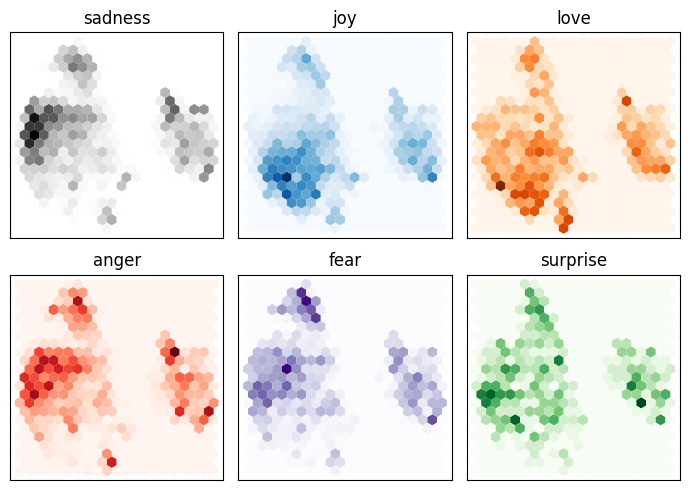

In [56]:
# Investigating the compressed data
# Observation 1: the negative feelings such as sadness, anger, and fear occupy similar regions
# Observation 2: the positive feelings joy and love are well separated from the negative emotions and also share a similar space
# Observation 3: the feeling surprise is scattered all over the place

fig, axes = plt.subplots(2, 3, figsize=(7,5))
axes = axes.flatten()
cmaps = ["Greys", "Blues", "Oranges", "Reds", "Purples", "Greens"]
labels = emotions["train"].features["label"].names

for i, (label, cmap) in enumerate(zip(labels, cmaps)):
    df_emb_sub = df_emb.query(f"label == {i}")
    axes[i].hexbin(df_emb_sub["X"], df_emb_sub["Y"], cmap=cmap,
                   gridsize=20, linewidths=(0,))
    axes[i].set_title(label)
    axes[i].set_xticks([]), axes[i].set_yticks([])

plt.tight_layout()
plt.show()

#### Training a Simple Classifier

In [57]:
# Tarinig the model

from sklearn.linear_model import LogisticRegression

# We increase `max_iter` to guarantee convergence
lr_clf = LogisticRegression(max_iter=3000)
lr_clf.fit(X_train, y_train)
lr_clf.score(X_valid, y_valid)

0.6345

In [58]:
# Compare our model to the dummy classifier
# Conclusion: 65% > 35%  - the classifier with DistilBERT embeddings is significantly better than the baseline (dummy classifier)

from sklearn.dummy import DummyClassifier

dummy_clf = DummyClassifier(strategy="most_frequent")
dummy_clf.fit(X_train, y_train)
dummy_clf.score(X_valid, y_valid)

0.352

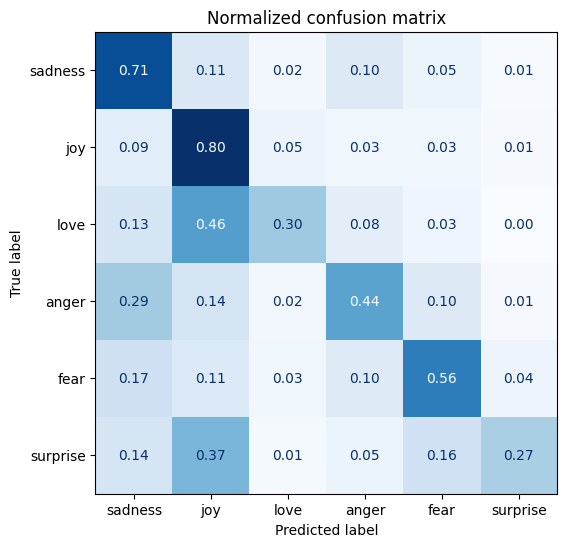

In [59]:
# Showing the confusion matrix
# Observation 1: anger and fear are most often confused with sadness
# Observation 2: love and surprise are frequently mistaken for joy

from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

def plot_confusion_matrix(y_preds, y_true, labels):
    cm = confusion_matrix(y_true, y_preds, normalize="true")
    fig, ax = plt.subplots(figsize=(6, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(cmap="Blues", values_format=".2f", ax=ax, colorbar=False)
    plt.title("Normalized confusion matrix")
    plt.show()

y_preds = lr_clf.predict(X_valid)
plot_confusion_matrix(y_preds, y_valid, labels)

### Fine-Tuning Transformers


#### Loading a Pretrained Model


In [60]:
# Use AutoModelForSequenceClassification model which has a classification head on top of the pretrained model outputs
# the classification head can be easily trained with the base model
# The model has to predict 6 labels

from transformers import AutoModelForSequenceClassification

num_labels = 6
model = (AutoModelForSequenceClassification
         .from_pretrained(model_ckpt, num_labels=num_labels)
         .to(device))

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


#### Defining the Performance Metrics


In [61]:
# Use the F1 score and accuracy for finetuning

from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    f1 = f1_score(labels, preds, average="weighted")
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc, "f1": f1}

#### Training the Model


In [62]:
# Log into Hugging Face Hub using the access token

from huggingface_hub import login
from google.colab import userdata

hf_token = userdata.get('HF_TOKEN')
login(hf_token)

In [63]:
# Definig model parameters

from transformers import Trainer, TrainingArguments

batch_size = 64
logging_steps = len(emotions_encoded["train"]) // batch_size
model_name = f"{model_ckpt}-finetuned-emotion"
training_args = TrainingArguments(output_dir=model_name,
                                  num_train_epochs=2,
                                  learning_rate=2e-5,
                                  per_device_train_batch_size=batch_size,
                                  per_device_eval_batch_size=batch_size,
                                  weight_decay=0.01,
                                  evaluation_strategy="epoch",
                                  disable_tqdm=False,
                                  logging_steps=logging_steps,
                                  push_to_hub=True,
                                  log_level="error")

/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1611: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


In [64]:
#pip install --upgrade transformers

In [65]:
from huggingface_hub import create_repo

# Replace 'model_name' with the desired name of your model repository
create_repo("model_name", repo_type="model")


RepoUrl('https://huggingface.co/hash7967/model_name', endpoint='https://huggingface.co', repo_type='model', repo_id='hash7967/model_name')

In [66]:
# Instantiate and finetune the model
# F1 score of 92% in vaildation dataset

from transformers import Trainer

trainer = Trainer(model=model, args=training_args,
                  compute_metrics=compute_metrics,
                  train_dataset=emotions_encoded["train"],
                  eval_dataset=emotions_encoded["validation"],
                  tokenizer=tokenizer)
trainer.train();

<ipython-input-66-eadf314f203c>:6: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(model=model, args=training_args,
wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: maihashad (maihashad-university-of-st-thomas) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.825500,0.316029,0.906000,0.904999
2,0.247300,0.214554,0.925000,0.924999


In [67]:
# Get the predicitions to use in calculating the confusion matrix

preds_output = trainer.predict(emotions_encoded["validation"])

In [68]:
# Show model metrics

preds_output.metrics

{'test_loss': 0.21455377340316772,
 'test_accuracy': 0.925,
 'test_f1': 0.9249992100963109,
 'test_runtime': 1.0236,
 'test_samples_per_second': 1953.883,
 'test_steps_per_second': 31.262}

In [69]:
# get predicted labels

y_preds = np.argmax(preds_output.predictions, axis=1)

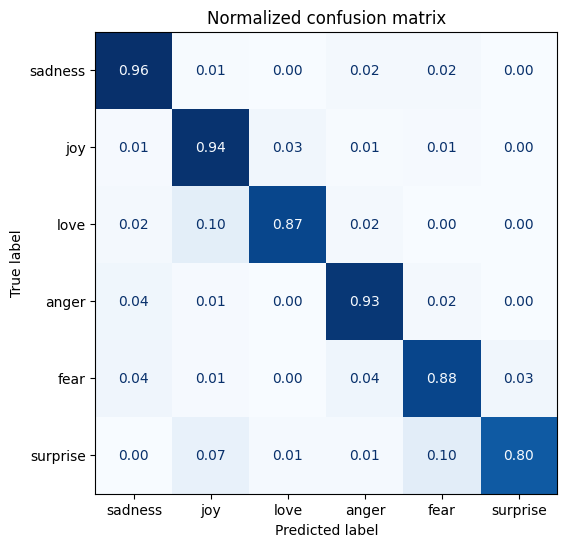

In [70]:
# Use the predicted labels vs true labels in validation dataset to calculate the confusion matrix

plot_confusion_matrix(y_preds, y_valid, labels)

#### Fine-Tuning with Keras


In [71]:
# Loading DistilBERT as a TensorFlow model

from transformers import TFAutoModelForSequenceClassification

tf_model = (TFAutoModelForSequenceClassification
            .from_pretrained(model_ckpt, num_labels=num_labels))

In [72]:
# The column names to convert to TensorFlow tensors
# The dataset converted into TF datasets
# Shuffled the training set and defined the batch size

tokenizer_columns = tokenizer.model_input_names

tf_train_dataset = emotions_encoded["train"].to_tf_dataset(
    columns=tokenizer_columns, label_cols=["label"], shuffle=True,
    batch_size=batch_size)
tf_eval_dataset = emotions_encoded["validation"].to_tf_dataset(
    columns=tokenizer_columns, label_cols=["label"], shuffle=False,
    batch_size=batch_size)

/usr/local/lib/python3.11/dist-packages/datasets/arrow_dataset.py:400: FutureWarning: The output of `to_tf_dataset` will change when a passing single element list for `labels` or `columns` in the next datasets version. To return a tuple structure rather than dict, pass a single string.
Old behaviour: columns=['a'], labels=['labels'] -> (tf.Tensor, tf.Tensor)  
             : columns='a', labels='labels' -> (tf.Tensor, tf.Tensor)  
New behaviour: columns=['a'],labels=['labels'] -> ({'a': tf.Tensor}, {'labels': tf.Tensor})  
             : columns='a', labels='labels' -> (tf.Tensor, tf.Tensor) 
  warnings.warn(


In [73]:
# Compile and train the model

import tensorflow as tf

tf_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-5),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=tf.metrics.SparseCategoricalAccuracy())

tf_model.fit(tf_train_dataset, validation_data=tf_eval_dataset, epochs=2)

Epoch 1/2
250/250 [==============================] - 49s 107ms/step - loss: 0.5297 - sparse_categorical_accuracy: 0.8158 - val_loss: 0.1866 - val_sparse_categorical_accuracy: 0.9275
Epoch 2/2
250/250 [==============================] - 17s 67ms/step - loss: 0.1404 - sparse_categorical_accuracy: 0.9385 - val_loss: 0.1612 - val_sparse_categorical_accuracy: 0.9285


#### Error Analysis


In [74]:
# Creates a function that returns the loss along with the predicted label in the forward propagation

from torch.nn.functional import cross_entropy

def forward_pass_with_label(batch):
    # Place all input tensors on the same device as the model
    inputs = {k:v.to(device) for k,v in batch.items()
              if k in tokenizer.model_input_names}

    with torch.no_grad():
        output = model(**inputs)
        pred_label = torch.argmax(output.logits, axis=-1)
        loss = cross_entropy(output.logits, batch["label"].to(device),
                             reduction="none")
    # Place outputs on CPU for compatibility with other dataset columns
    return {"loss": loss.cpu().numpy(),
            "predicted_label": pred_label.cpu().numpy()}

In [75]:
# Convert our dataset back to PyTorch tensors
emotions_encoded.set_format("torch",
                            columns=["input_ids", "attention_mask", "label"])
# Compute loss values
emotions_encoded["validation"] = emotions_encoded["validation"].map(
    forward_pass_with_label, batched=True, batch_size=16)

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [76]:
# Create a DataFrame with the texts, losses, and predicted/true labels

emotions_encoded.set_format("pandas")
cols = ["text", "label", "predicted_label", "loss"]
df_test = emotions_encoded["validation"][:][cols]
df_test["label"] = df_test["label"].apply(label_int2str)
df_test["predicted_label"] = (df_test["predicted_label"]
                              .apply(label_int2str))

In [77]:
# Showing the sampled with the highest losses
# Observation: joy is sometimes mislabeled

df_test.sort_values("loss", ascending=False).head(10)

,text,label,predicted_label,loss
1963,i called myself pro life and voted for perry w...,joy,sadness,5.486725
882,i feel badly about reneging on my commitment t...,love,sadness,5.400959
1870,i guess i feel betrayed because i admired him ...,joy,sadness,5.277161
1509,i guess this is a memoir so it feels like that...,joy,fear,5.254717
1950,i as representative of everything thats wrong ...,surprise,anger,5.152139
1274,i am going to several holiday parties and i ca...,joy,sadness,5.052275
465,i would eventually go in to these stores but i...,joy,fear,5.019020
1801,i feel that he was being overshadowed by the s...,love,sadness,4.860253
1500,i guess we would naturally feel a sense of lon...,anger,sadness,4.821657
765,i feel super awkward and out of place right now,joy,sadness,4.608036


In [78]:
# Showing the sampled with the lowest losses

df_test.sort_values("loss", ascending=True).head(10)

,text,label,predicted_label,loss
1873,i feel practically virtuous this month i have ...,joy,joy,0.015965
11,i was dribbling on mums coffee table looking o...,joy,joy,0.016366
1618,i had a good feeling about the presentation an...,joy,joy,0.016430
1263,i feel this way about blake lively,joy,joy,0.016460
317,i also loved bruise brothers it was so much fu...,joy,joy,0.016466
941,i expected but it did feel hopeful and it defi...,joy,joy,0.016474
578,i got to christmas feeling positive about the ...,joy,joy,0.016573
1589,i feel a strong shift recently,joy,joy,0.016574
1012,i definitely succumbed to pre holiday sales bu...,joy,joy,0.016577
737,im so grateful to feel peaceful at the end of ...,joy,joy,0.016587


#### Saving and Sharing the Model


In [79]:
# Use the Trainer API to save and share the model

trainer.push_to_hub(commit_message="Training completed!")

events.out.tfevents.1743045113.a783bed5c3b8.5368.0:   0%|          | 0.00/6.79k [00:00<?, ?B/s]

CommitInfo(commit_url='https://huggingface.co/hash7967/distilbert-base-uncased-finetuned-emotion/commit/788ea92ed208ac6acf89cc94732e963151f08244', commit_message='Training completed!', commit_description='', oid='788ea92ed208ac6acf89cc94732e963151f08244', pr_url=None, repo_url=RepoUrl('https://huggingface.co/hash7967/distilbert-base-uncased-finetuned-emotion', endpoint='https://huggingface.co', repo_type='model', repo_id='hash7967/distilbert-base-uncased-finetuned-emotion'), pr_revision=None, pr_num=None)

In [80]:
# Use the model on new tweets

from transformers import pipeline

model_id = "hash7967/distilbert-base-uncased-finetuned-emotion"
classifier = pipeline("text-classification", model=model_id)

config.json:   0%|          | 0.00/837 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.23k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

In [81]:
# Test the pipeline on a new tweet

custom_tweet = "I saw a movie today and it was really good."
preds = classifier(custom_tweet, return_all_scores=True)

/usr/local/lib/python3.11/dist-packages/transformers/pipelines/text_classification.py:106: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(


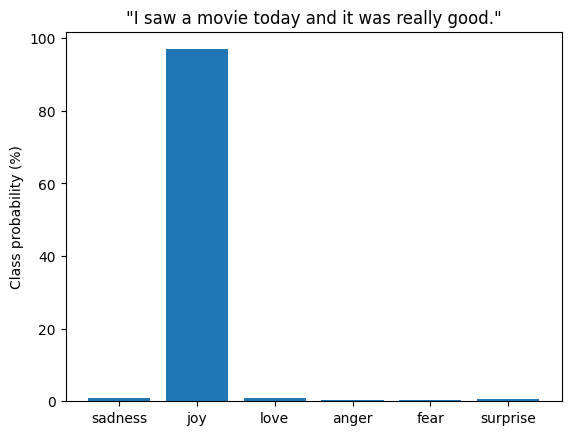

In [82]:
#  Plot the probability for each class

preds_df = pd.DataFrame(preds[0])
plt.bar(labels, 100 * preds_df["score"], color='C0')
plt.title(f'"{custom_tweet}"')
plt.ylabel("Class probability (%)")
plt.show()

# LaTeX


$$ \bar{x} = \begin{bmatrix} x_1 & x_2 & x_3 & \dots & x_M \end{bmatrix}^T $$


$$ y = \beta + w_1x_1 + w_2x_2 + \dots + w_M x_M $$


$$ y = w_0 + w_1x_1 + w_2x_2 + \dots + w_M x_M $$


$$ y = W \overline{x} $$

$$ \begin{pmatrix} y_1 \\ y_2 \\ y_3 \\ \dots \\ y_N \end{pmatrix}
=
\begin{pmatrix}
1 & x_{1,1} & x_{1,2} & \dots & x_{1,M} \\
1 & x_{2,1} & x_{2,2} & \dots & x_{2,M} \\
1 & x_{3,1} & x_{3,2} & \dots & x_{3,M} \\
\dots & \dots & \dots & \dots & \dots \\
1 & x_{N,1} & x_{N,2} & \dots & x_{N,M}
\end{pmatrix} * \begin{pmatrix} w_0 \\ w_1 \\ w_2 \\ \dots \\ w_M \end{pmatrix}$$


$$ Y = X W $$

$$
y_{\text{out}} = \frac{1}{1 + e^{-y_{\text{in}}}}  =  \frac{e^{y_{\text{in}}}}{e^{y_{\text{in}}} + 1}
$$


$$
\begin{pmatrix}
y_{1,1} & y_{1,2} & \dots & y_{1,Q} \\
y_{2,1} & y_{2,2} & \dots & y_{2,Q} \\
y_{3,1} & y_{3,2} & \dots & y_{3,Q} \\
\dots & \dots & \dots & \dots \\
y_{N,1} & y_{N,2} & \dots & y_{N,Q}
\end{pmatrix}
=
\begin{pmatrix}
1 & x_{1,1} & x_{1,2} & \dots & x_{1,M} \\
1 & x_{2,1} & x_{2,2} & \dots & x_{2,M} \\
1 & x_{3,1} & x_{3,2} & \dots & x_{3,M} \\
\dots & \dots & \dots & \dots & \dots \\
1 & x_{N,1} & x_{N,2} & \dots & x_{N,M}
\end{pmatrix}
*
\begin{pmatrix}
w_{0,1} & w_{0,2} & \dots & w_{0,Q} \\
w_{1,1} & w_{1,2} & \dots & w_{1,Q} \\
w_{2,1} & w_{2,2} & \dots & w_{2,Q} \\
\dots & \dots & \dots & \dots & \dots \\
w_{M,1} & w_{M,2} & \dots & w_{M,Q}
\end{pmatrix}
$$

$$
P(B | E) = \frac{P(B) P(E | B)}{P(E)}
$$


$$
P(T | S) = \frac{P(T) P(S | T)}{P(S)}
$$


# Questions


I was wondering if we can go over creating a model in HuggingFace Hub